In [1]:
from pathlib import Path
import warnings

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import nymeria_gaze_tools as ngt

pio.renderers.default = "notebook_connected"

DATA_ROOT      = Path("../data/processed")
SUMMARIES_PATH = DATA_ROOT / "all_session_summaries.csv"
FIGURES_DIR    = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

TARGET_ACTIVITIES = [
    "S18-Hike",
    "S2-Where_is_X",
    "S7-Cooking",
    "S10-Housekeeping",
    "S20-Party",
    "S13-Charades",
    "S11-Laundary",
    "S12-Game_night",
    "S8-Having_a_meal",
]

print("Setup complete.")

Setup complete.


In [2]:
catalog_raw = ngt.load_metadata(data_root=DATA_ROOT)

catalog = catalog_raw.copy()
catalog = catalog[catalog["sampling_rate_hz"] == 10]
catalog = catalog[catalog["noise_flag"] == False]
catalog = catalog[catalog["has_gaze_data"] == True]
catalog = catalog[catalog["has_two_participants"] == False]
catalog = (catalog
           .sort_values("date")
           .drop_duplicates(["fake_name", "script"])
           .reset_index(drop=True))

# Restrict to the 9 target activities
catalog = catalog[catalog["script"].isin(TARGET_ACTIVITIES)].reset_index(drop=True)

print(f"Sessions: {len(catalog)}  |  Participants: {catalog['fake_name'].nunique()}")
print(f"\nSessions per activity:")
print(catalog.groupby("script").size().sort_values(ascending=False).to_string())


Sessions: 467  |  Participants: 187

Sessions per activity:
script
S7-Cooking          97
S2-Where_is_X       96
S12-Game_night      89
S10-Housekeeping    54
S8-Having_a_meal    46
S11-Laundary        28
S13-Charades        27
S18-Hike            17
S20-Party           13


In [3]:
print(f"Loading {len(catalog)} sessions...")
session_dfs = {}
skipped = []

for i, (_, row) in enumerate(catalog.iterrows()):
    if i % 50 == 0:
        print(f"  {i}/{len(catalog)}")
    try:
        raw = ngt.load_session(row["sequence_uid"], data_root=DATA_ROOT)
        session_dfs[row["sequence_uid"]] = ngt.preprocess(
            raw,
            trim_start_min=row["trim_start_sec"] / 60,
            trim_end_min=row["trim_end_sec"] / 60,
        )
    except Exception as e:
        skipped.append((row["sequence_uid"], row["script"], str(e)))

print(f"\nDone. Loaded: {len(session_dfs)}  |  Skipped: {len(skipped)}")
for uid, script, err in skipped:
    print(f"  SKIP {script} | {uid} | {err}")


Loading 467 sessions...
  0/467
  50/467
  100/467
  150/467
  200/467
  250/467
  300/467
  350/467
  400/467
  450/467

Done. Loaded: 467  |  Skipped: 0


In [4]:
activity_groups = {}
for _, row in catalog.iterrows():
    uid = row["sequence_uid"]
    if uid not in session_dfs:
        continue
    script = row["script"]
    if script not in activity_groups:
        activity_groups[script] = []
    activity_groups[script].append(session_dfs[uid])

print("Sessions per activity (loaded):")
for script in TARGET_ACTIVITIES:
    n = len(activity_groups.get(script, []))
    print(f"  {script:<35} {n}")


Sessions per activity (loaded):
  S18-Hike                            17
  S2-Where_is_X                       96
  S7-Cooking                          97
  S10-Housekeeping                    54
  S20-Party                           13
  S13-Charades                        27
  S11-Laundary                        28
  S12-Game_night                      89
  S8-Having_a_meal                    46


In [5]:
rows = []
for _, meta_row in catalog.iterrows():
    uid = meta_row["sequence_uid"]
    if uid not in session_dfs:
        continue
    df = session_dfs[uid]
    rows.append({
        "script":     meta_row["script"],
        "fake_name":  meta_row["fake_name"],
        "mean_yaw":   df["avg_yaw_deg"].mean(),
        "mean_pitch": df["pitch_deg"].mean(),
    })

participant_means = pd.DataFrame(rows)

centroids = (participant_means
             .groupby("script")
             .agg(
                 centroid_yaw   = ("mean_yaw",   "mean"),
                 centroid_pitch = ("mean_pitch",  "mean"),
                 yaw_se         = ("mean_yaw",   "sem"),
                 pitch_se       = ("mean_pitch", "sem"),
                 n              = ("fake_name",  "count"),
             )
             .reset_index())

print(centroids.sort_values("centroid_pitch").to_string())


             script  centroid_yaw  centroid_pitch    yaw_se  pitch_se   n
7        S7-Cooking     -0.185811      -24.173930  0.216911  0.565328  97
1      S11-Laundary     -1.467380      -23.249288  0.382068  1.171910  28
6         S20-Party      0.770476      -22.045968  0.511901  1.094097  13
0  S10-Housekeeping     -0.176776      -21.178431  0.272652  0.723588  54
8  S8-Having_a_meal     -0.004549      -20.414237  0.362617  0.889868  46
2    S12-Game_night     -0.590211      -20.341244  0.252623  0.604013  89
4          S18-Hike      0.903323      -18.918486  0.502643  1.044961  17
5     S2-Where_is_X     -0.180405      -16.438659  0.227995  0.511304  96
3      S13-Charades     -1.084560      -14.329010  0.507147  1.130615  27


In [6]:
BINS       = 80
N_COLS     = 3
PANEL_SIZE = 300

activity_order = (centroids
                  .sort_values("centroid_pitch")["script"]
                  .tolist())

groups = {act: activity_groups[act] for act in activity_order}
labels = list(groups.keys())
n      = len(labels)
n_rows = math.ceil(n / N_COLS)

all_dfs = [df for dfs in groups.values() for df in dfs]
x_all   = pd.concat([df["avg_yaw_deg"].dropna() for df in all_dfs])
y_all   = pd.concat([df["pitch_deg"].dropna()   for df in all_dfs])
x_edges = np.linspace(x_all.min(), x_all.max(), BINS + 1)
y_edges = np.linspace(y_all.min(), y_all.max(), BINS + 1)
x_ctr   = (x_edges[:-1] + x_edges[1:]) / 2
y_ctr   = (y_edges[:-1] + y_edges[1:]) / 2

z_maps = {}
for lbl, dfs in groups.items():
    maps = []
    for df in dfs:
        h, _, _ = np.histogram2d(df["avg_yaw_deg"].dropna(), df["pitch_deg"].dropna(),
                                 bins=[x_edges, y_edges])
        if h.sum() > 0:
            maps.append(h / h.sum())
    z_maps[lbl] = np.mean(maps, axis=0).T if maps else np.zeros((BINS, BINS))

# Shared color range across all panels
zmin = min(z.min() for z in z_maps.values())
zmax = max(z.max() for z in z_maps.values())

subplot_titles = [
    f"{lbl.split('-', 1)[1].replace('_', ' ')}  (n={len(groups[lbl])})"
    for lbl in labels
]

fig = make_subplots(
    rows=n_rows, cols=N_COLS,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

for idx, lbl in enumerate(labels):
    row = idx // N_COLS + 1
    col = idx % N_COLS + 1
    is_last = idx == len(labels) - 1
    fig.add_trace(
        go.Heatmap(
            x=x_ctr, y=y_ctr, z=z_maps[lbl],
            colorscale="viridis",
            zmin=zmin, zmax=zmax,
            showscale=is_last,
            colorbar=dict(title="Density", thickness=15, len=0.5, y=0.2) if is_last else None,
        ),
        row=row, col=col,
    )
    fig.add_hline(y=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)
    fig.add_vline(x=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)

fig.update_layout(
    title_text="Population Gaze Density by Activity  (sorted most downward → least)",
    width=PANEL_SIZE * N_COLS + 180,
    height=PANEL_SIZE * n_rows + 120,
    autosize=False,
)
fig.show()


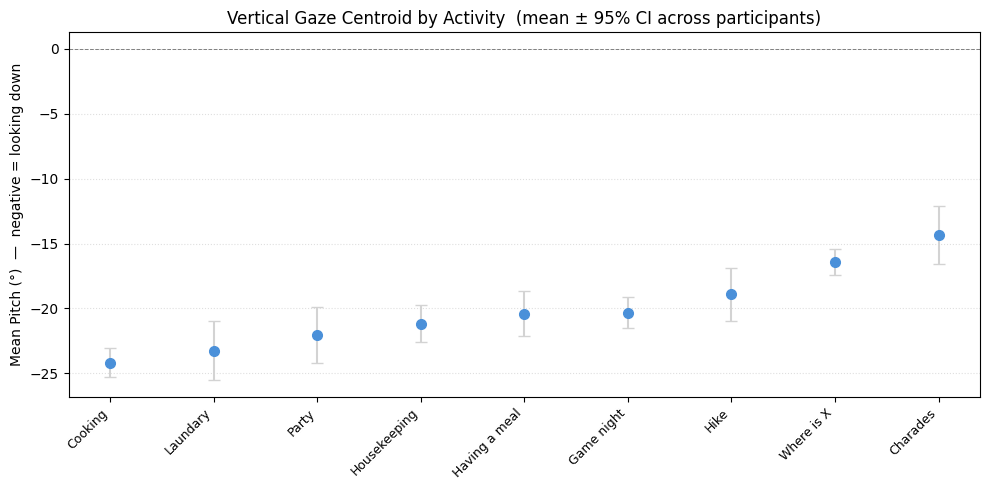

In [7]:
plot_centroids = centroids.sort_values("centroid_pitch").reset_index(drop=True)
tick_labels = plot_centroids["script"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x=range(len(plot_centroids)),
    y=plot_centroids["centroid_pitch"],
    yerr=plot_centroids["pitch_se"] * 1.96,
    fmt="o", color="#4a90d9", ecolor="lightgray",
    elinewidth=1.5, capsize=4, markersize=7
)

ax.set_xticks(range(len(plot_centroids)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down")
ax.set_title("Vertical Gaze Centroid by Activity  (mean ± 95% CI across participants)")
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "9act_pitch_centroids.png", dpi=150, bbox_inches="tight")
plt.show()

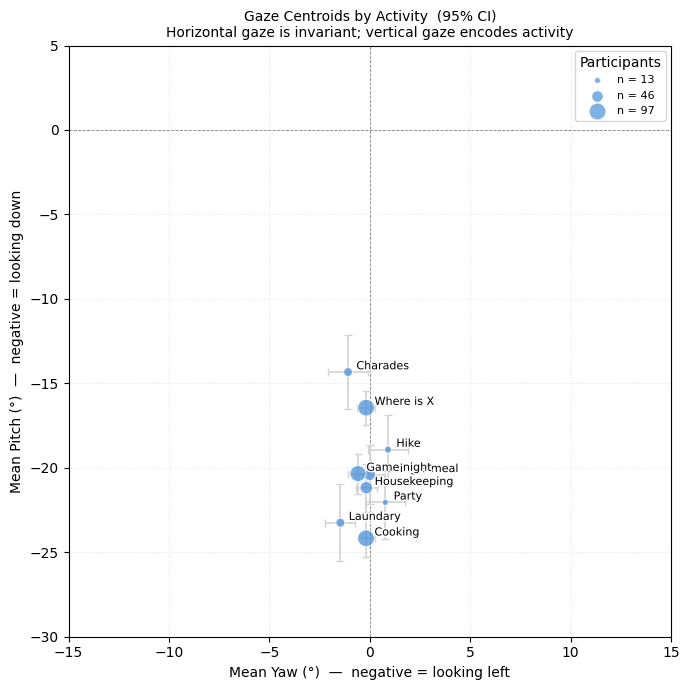

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    plot_centroids["centroid_yaw"],
    plot_centroids["centroid_pitch"],
    s=plot_centroids["n"] * 1.5,
    color="#4a90d9", alpha=0.75, zorder=3, edgecolors="white", linewidths=0.8
)

ax.errorbar(
    plot_centroids["centroid_yaw"],
    plot_centroids["centroid_pitch"],
    xerr=plot_centroids["yaw_se"] * 1.96,
    yerr=plot_centroids["pitch_se"] * 1.96,
    fmt="none", ecolor="lightgray", elinewidth=1.2, capsize=3, zorder=2
)

for _, row in plot_centroids.iterrows():
    label = row["script"].split("-", 1)[1].replace("_", " ")
    ax.annotate(
        label,
        (row["centroid_yaw"], row["centroid_pitch"]),
        textcoords="offset points", xytext=(6, 2),
        fontsize=8,
        path_effects=[pe.withStroke(linewidth=2, foreground="white")]
    )

ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", zorder=1)
ax.axvline(0, color="gray", linewidth=0.6, linestyle="--", zorder=1)
ax.set_xlim(-15, 15)
ax.set_ylim(-30, 5)
ax.set_xlabel("Mean Yaw (°)  —  negative = looking left", fontsize=10)
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down", fontsize=10)
ax.set_title("Gaze Centroids by Activity  (95% CI)\nHorizontal gaze is invariant; vertical gaze encodes activity", fontsize=10)
ax.grid(linestyle=":", alpha=0.3)

for n_val in [13, 46, 97]:
    ax.scatter([], [], s=n_val * 1.5, color="#4a90d9", alpha=0.7,
               label=f"n = {n_val}", edgecolors="white", linewidths=0.8)
ax.legend(title="Participants", framealpha=0.8, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "9act_centroids_2d.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
var_maps = {}
for lbl, dfs in groups.items():
    maps = []
    for df in dfs:
        h, _, _ = np.histogram2d(df["avg_yaw_deg"].dropna(), df["pitch_deg"].dropna(),
                                 bins=[x_edges, y_edges])
        if h.sum() > 0:
            maps.append(h / h.sum())
    var_maps[lbl] = np.var(maps, axis=0).T if len(maps) > 1 else np.zeros((BINS, BINS))

# Clip to 99th percentile so outlier spikes don't dominate the colorscale
all_var_values = np.concatenate([v.ravel() for v in var_maps.values()])
zmin_var = 0
zmax_var = np.percentile(all_var_values, 99)

print(f"zmax clipped to 99th percentile: {zmax_var:.2e}  (raw max: {all_var_values.max():.2e})")

fig = make_subplots(
    rows=n_rows, cols=N_COLS,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

for idx, lbl in enumerate(labels):
    row = idx // N_COLS + 1
    col = idx % N_COLS + 1
    is_last = idx == len(labels) - 1
    fig.add_trace(
        go.Heatmap(
            x=x_ctr, y=y_ctr, z=var_maps[lbl],
            colorscale="inferno",
            zmin=zmin_var, zmax=zmax_var,
            showscale=is_last,
            colorbar=dict(title="Variance", thickness=15, len=0.5, y=0.2) if is_last else None,
        ),
        row=row, col=col,
    )
    fig.add_hline(y=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)
    fig.add_vline(x=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)

fig.update_layout(
    title_text="Per-Pixel Gaze Variance by Activity  (bright = high disagreement across participants)",
    width=PANEL_SIZE * N_COLS + 180,
    height=PANEL_SIZE * n_rows + 120,
    autosize=False,
)
fig.show()


zmax clipped to 99th percentile: 4.35e-06  (raw max: 1.40e-04)


             script  pitch_sd    yaw_sd   n
0         S20-Party  3.944822  1.845685  13
1          S18-Hike  4.308485  2.072448  17
2     S2-Where_is_X  5.009736  2.233888  96
3  S10-Housekeeping  5.317265  2.003575  54
4        S7-Cooking  5.567835  2.136323  97
5    S12-Game_night  5.698249  2.383240  89
6      S13-Charades  5.874845  2.635213  27
7  S8-Having_a_meal  6.035380  2.459389  46
8      S11-Laundary  6.201164  2.021713  28


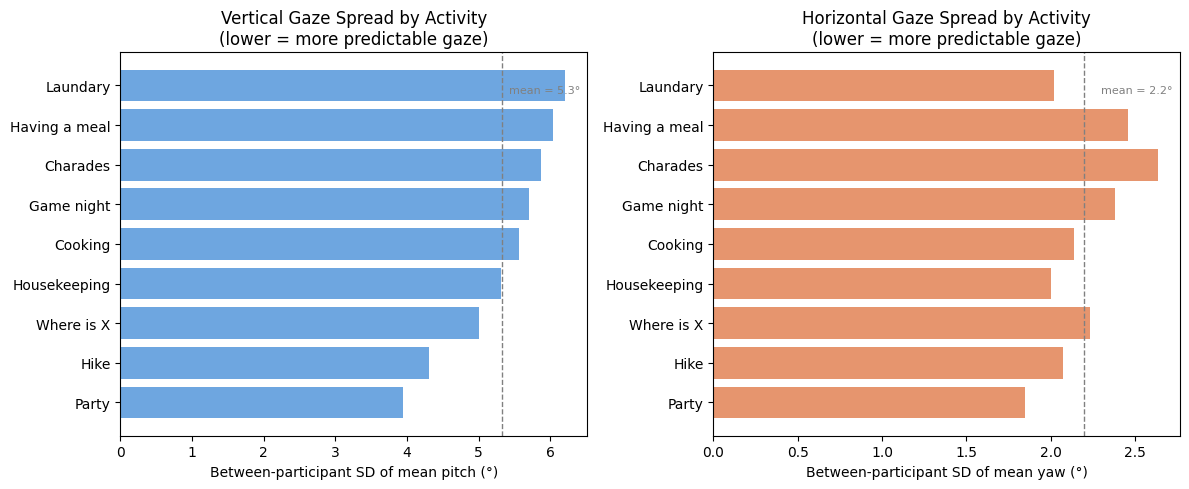

In [13]:
spread = (participant_means
          .groupby("script")
          .agg(
              pitch_sd = ("mean_pitch", "std"),
              yaw_sd   = ("mean_yaw",   "std"),
              n        = ("fake_name",  "count"),
          )
          .reset_index()
          .sort_values("pitch_sd")
          .reset_index(drop=True))

print(spread.to_string())

labels_spread = spread["script"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.barh(labels_spread, spread["pitch_sd"], color="#4a90d9", alpha=0.8)
ax.axvline(spread["pitch_sd"].mean(), color="gray", linestyle="--", linewidth=1)
ax.text(spread["pitch_sd"].mean() + 0.1, len(spread) - 1,
        f"mean = {spread['pitch_sd'].mean():.1f}°", fontsize=8, va="top", color="gray")
ax.set_xlabel("Between-participant SD of mean pitch (°)")
ax.set_title("Vertical Gaze Spread by Activity\n(lower = more predictable gaze)")

ax = axes[1]
ax.barh(labels_spread, spread["yaw_sd"], color="#e07b4a", alpha=0.8)
ax.axvline(spread["yaw_sd"].mean(), color="gray", linestyle="--", linewidth=1)
ax.text(spread["yaw_sd"].mean() + 0.1, len(spread) - 1,
        f"mean = {spread['yaw_sd'].mean():.1f}°", fontsize=8, va="top", color="gray")
ax.set_xlabel("Between-participant SD of mean yaw (°)")
ax.set_title("Horizontal Gaze Spread by Activity\n(lower = more predictable gaze)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "9act_gaze_spread.png", dpi=150, bbox_inches="tight")
plt.show()


Between-participant SD in mean pitch ranged from 4.0° to 6.3° across activities (yaw: 1.8° to 2.6°), indicating comparable within-activity consistency. The figure above may be dropped in favour of this summary.

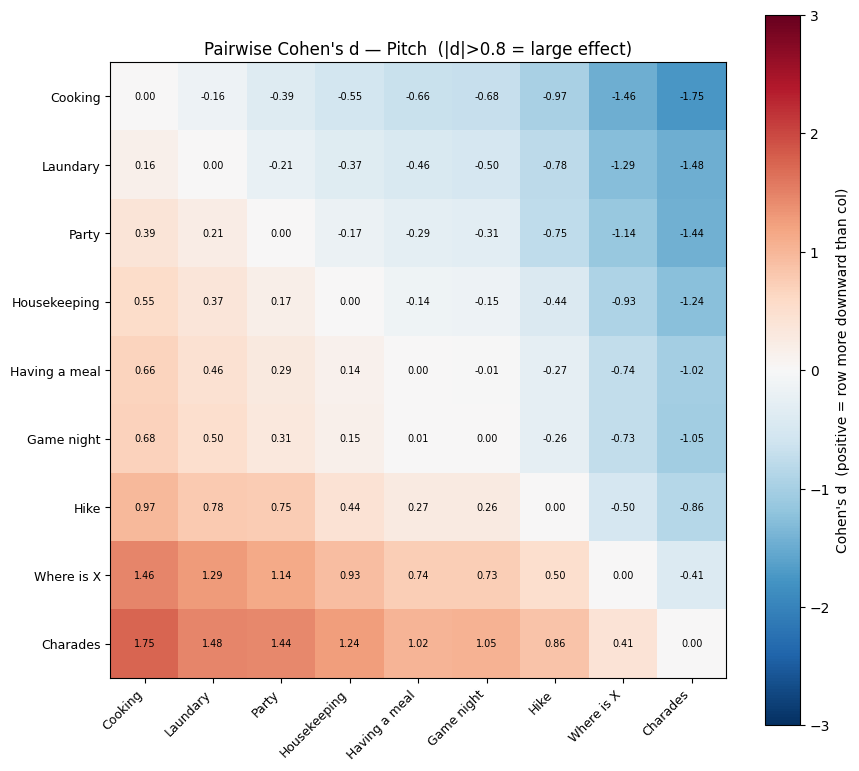

In [11]:
from itertools import combinations

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd

activity_labels = [s.split("-", 1)[1].replace("_", " ") for s in TARGET_ACTIVITIES]
scripts = TARGET_ACTIVITIES

d_matrix = pd.DataFrame(np.nan, index=activity_labels, columns=activity_labels)

for act in activity_labels:
    d_matrix.loc[act, act] = 0.0

for s1, s2 in combinations(scripts, 2):
    a = participant_means[participant_means["script"] == s1]["mean_pitch"].values
    b = participant_means[participant_means["script"] == s2]["mean_pitch"].values
    d = cohens_d(a, b)
    l1 = s1.split("-", 1)[1].replace("_", " ")
    l2 = s2.split("-", 1)[1].replace("_", " ")
    d_matrix.loc[l1, l2] = d
    d_matrix.loc[l2, l1] = -d

# Sort by centroid pitch so most-downward activities are top-left
pitch_order = (centroids.sort_values("centroid_pitch")["script"]
               .apply(lambda s: s.split("-", 1)[1].replace("_", " "))
               .tolist())
d_matrix = d_matrix.loc[pitch_order, pitch_order]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(d_matrix.values.astype(float), cmap="RdBu_r", vmin=-3, vmax=3)
plt.colorbar(im, ax=ax, label="Cohen's d  (positive = row more downward than col)")

ax.set_xticks(range(len(pitch_order)))
ax.set_yticks(range(len(pitch_order)))
ax.set_xticklabels(pitch_order, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pitch_order, fontsize=9)

for i in range(len(pitch_order)):
    for j in range(len(pitch_order)):
        val = d_matrix.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if abs(val) < 2 else "white")

ax.set_title("Pairwise Cohen's d — Pitch  (|d|>0.8 = large effect)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "9act_cohens_d_pitch.png", dpi=150, bbox_inches="tight")
plt.show()
